In [1]:
%load_ext autoreload
%autoreload 2

from blochK import Hamiltonian3D
import numpy as np
from numpy import pi,cos,sin,exp

import matplotlib.pyplot as plt
import matplotlib

from blochK.plotting.utils import extent #for getting the correct extent

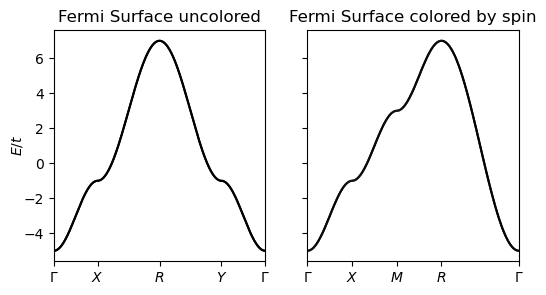

In [2]:
from blochK.hamiltonian_testing import H3Dsquare_fct

H = Hamiltonian3D(H3Dsquare_fct, n1=np.array([1,0,0]), n2=np.array([0,1,0]), n3=np.array([0,0,1]))  # empty Hamiltonian3D object for testing
H.add_operator('spin', np.array([1,-1]))  # add spin operator

from blochK.plotting import plot_bandstruc


#define a path in the BZ
labels_points_path = [r'\Gamma','X','M','R',r'\Gamma'] #this is also the default
#the right points are automatically found from the BZ points

fig,axs = plt.subplots(1,2, figsize=(6,3))

axs[0].set_title('Fermi Surface uncolored')
plot_bandstruc(axs[0], H, N_samples=100, coloring_operator='k')

axs[1].set_title('Fermi Surface colored by spin')
plot_bandstruc(axs[1], H, N_samples=100,labels_points_path=labels_points_path, coloring_operator=H.operator.spin,cmap='bwr',show_ylabel=False)

In [ ]:
import pyvista as pv

def make_pyvista_mesh(vertices, faces):
    face_array = []
    for f in faces:
        face_array.append(len(f))
        face_array.extend(f)
    face_array = np.array(face_array)
    return pv.PolyData(vertices, face_array)


vertices, faces = H.BZ.return_boundary()
mesh = make_pyvista_mesh(vertices, faces)

plotter = pv.Plotter()
plotter.add_mesh(mesh, style='wireframe', color='black', line_width=2)
# or as a translucent solid:
# plotter.add_mesh(mesh, color='cyan', opacity=0.3, show_edges=True)
plotter.show()

ModuleNotFoundError: No module named 'pyvista'

In [4]:
vertices, faces = H.BZ.return_boundary()

In [13]:
H.BZ.m2

array([0.        , 6.28318531, 0.        ])